# 2. Event Definition Notebook

This notebook guides you through the process of defining, analyzing, and visualizing a extreme metereological event.

---

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervention </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  



## Setup and User Inputs
This section prepares the environment for running the analysis.


### <font color="green"> Import require packages </font>

In [1]:
# Imports
from c3s_lib import *
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import json
import geopandas as gpd
import xarray as xr
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import math
import calendar
import os
 


### <font color="orange"> User specifications </font>

In [2]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
################# (User selection) ###################
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'
######################################################

# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file

################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################
os.makedirs(your_save_directory, exist_ok=True) # create directory if it does not exist


## <font color="orange"> 2.1 Choice of parameter </font>

In [3]:
# Choice of parameter (Tmax, Tmean, Tmin, Precipitation)
################# (User selection) ###################
parameter = "Precipitation" 
######################################################

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin"]:
    variable = "Temperature"
    value_col = "t2m"
    y_label = "c"
    unit = "°C"
    calculation = "absolute"  # absolute or relative
    method = "Mean" 
elif parameter == "Precipitation":
    variable = "Precipitation"
    value_col = "tp"
    y_label = "mm"
    unit = "mm"
    calculation = "relative"  # absolute or relative
    method = "Total"

# title = f"2m {parameter} Anomaly ({y_label})"

## <font color="orange"> 2.2 Choice of area </font>

In [4]:

################# (User selection) ###################
# Area of interest (min lon, min lat, max lon, max lat)
bbox = (-82, 0, -75, 11) # Colombia
#bbox = (-110, 18, -95, 32) # Mexico temperature
#bbox = (-65,-40,-55,-30) # Uruguay
#bbox = (-104, 15, -90, 28) # Mexico precipitation

# Date of the event
event_end = datetime(2023, 10, 10)
######################################################

# Date of days leading up to the event
event_start = event_end - timedelta(days=14)


## 2.2.a.i Prepare Climate Data and Visualize event daily maps
In this step, you will download daily data for the selected climate parameter (e.g., temperature, precipitation) 
from the **ERA5/Beacon** dataset. The data will be divided into two key time periods:

- **Event period** - the days leading up to and including the event.  
- **Climatology period** - a long-term reference window (typically 1991–2020).

Finally, you will visualize the event evolution over time with daily maps.

### <font color="green"> Download the Daily Dataset for the Chosen Variable </font>
This cell connects to the CDS and ERA5/Beacon API and retrieves daily gridded data for your area of interest, from 1950 up to the event date.

In [5]:
# Run code to fetch data using beacon
gr_daily = DataClient(your_api_key, beacon_cache_url='https://beacon-era5.maris.nl/').GET(parameter=parameter, bbox=bbox, time_range=(datetime(1951,1,1), event_end), to_unit=y_label)
print(gr_daily)
# Datetime column
datetime_col = 'valid_time'
print ("selected value column:", value_col)
print ("selected datetime column:", datetime_col)

Connected to: https://beacon-era5.maris.nl/ server successfully
Connected to: https://beacon-era5.maris.nl/ server successfully
Fetching data from beacon cache...
Beacon Bbox: (278.0, 0, 285.0, 11)
Running query: {"from": "era5_daily_total_precipitation", "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "tp", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 278.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 285.0}, {"column": "latitude", "gt_eq": 0, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": 11}]}, {"column": "valid_time", "gt_eq": "1951-01-01T00:00:00.000000", "lt_eq": "2023-10-10T00:00:00.000000"}], "output": {"format": "parquet"}}
Converted from m/h to mm.
Beacon cache covers time range: 1951-01-01 00:00:00 - 2023-10-10 00:00:00
          longitude  latitude valid_time        tp           geometry
0             -82.0      0.00 195

### <font color="green"> Define the Event Period and Climatology Period datasets </font>
The dataset is divided into two parts: the event period and the long-term climatology period (e.g., 1991–2020).

In [6]:
# Specify climatology dates 
clim_start = datetime(1991, 1, 1)
clim_end = datetime(2020, 12, 31)


# Sort gdf, this is needed when the era5 set gets merged with the beacon set
gr_daily = gr_daily.sort_values(by=datetime_col)

# Select event subset
gr_daily_eventNdays = subset_gdf(gdf=gr_daily, datetime_col=datetime_col, date_range=(event_start, event_end))

# Select climatology subset
gr_daily_clim = subset_gdf(gdf=gr_daily, datetime_col=datetime_col, date_range=(clim_start, clim_end))

# needs a better print of the resulting dataframes
print(gr_daily_clim)
print(gr_daily_eventNdays)

          longitude  latitude valid_time          tp             geometry
19066924     -77.25      4.75 1991-01-01  110.696793  POINT (-77.25 4.75)
19066923     -77.25      4.50 1991-01-01  205.986969   POINT (-77.25 4.5)
19066922     -77.25      4.25 1991-01-01  210.648071  POINT (-77.25 4.25)
19066921     -77.25      4.00 1991-01-01  172.999863     POINT (-77.25 4)
19066920     -77.25      3.75 1991-01-01  158.934113  POINT (-77.25 3.75)
...             ...       ...        ...         ...                  ...
33365367     -79.75      6.75 2020-12-31    2.888680  POINT (-79.75 6.75)
33365366     -79.75      6.50 2020-12-31    3.133774   POINT (-79.75 6.5)
33365365     -79.75      6.25 2020-12-31    2.731323  POINT (-79.75 6.25)
33365364     -79.75      6.00 2020-12-31    3.359318     POINT (-79.75 6)
33365371     -79.75      7.75 2020-12-31    2.363205  POINT (-79.75 7.75)

[14300190 rows x 5 columns]
          longitude  latitude valid_time         tp             geometry
34669503  

### <font color="green"> Visualize Daily Maps Before and During the Event </font>
A sequence of daily maps is produced to show how the variable evolved in the 15 days before the event.

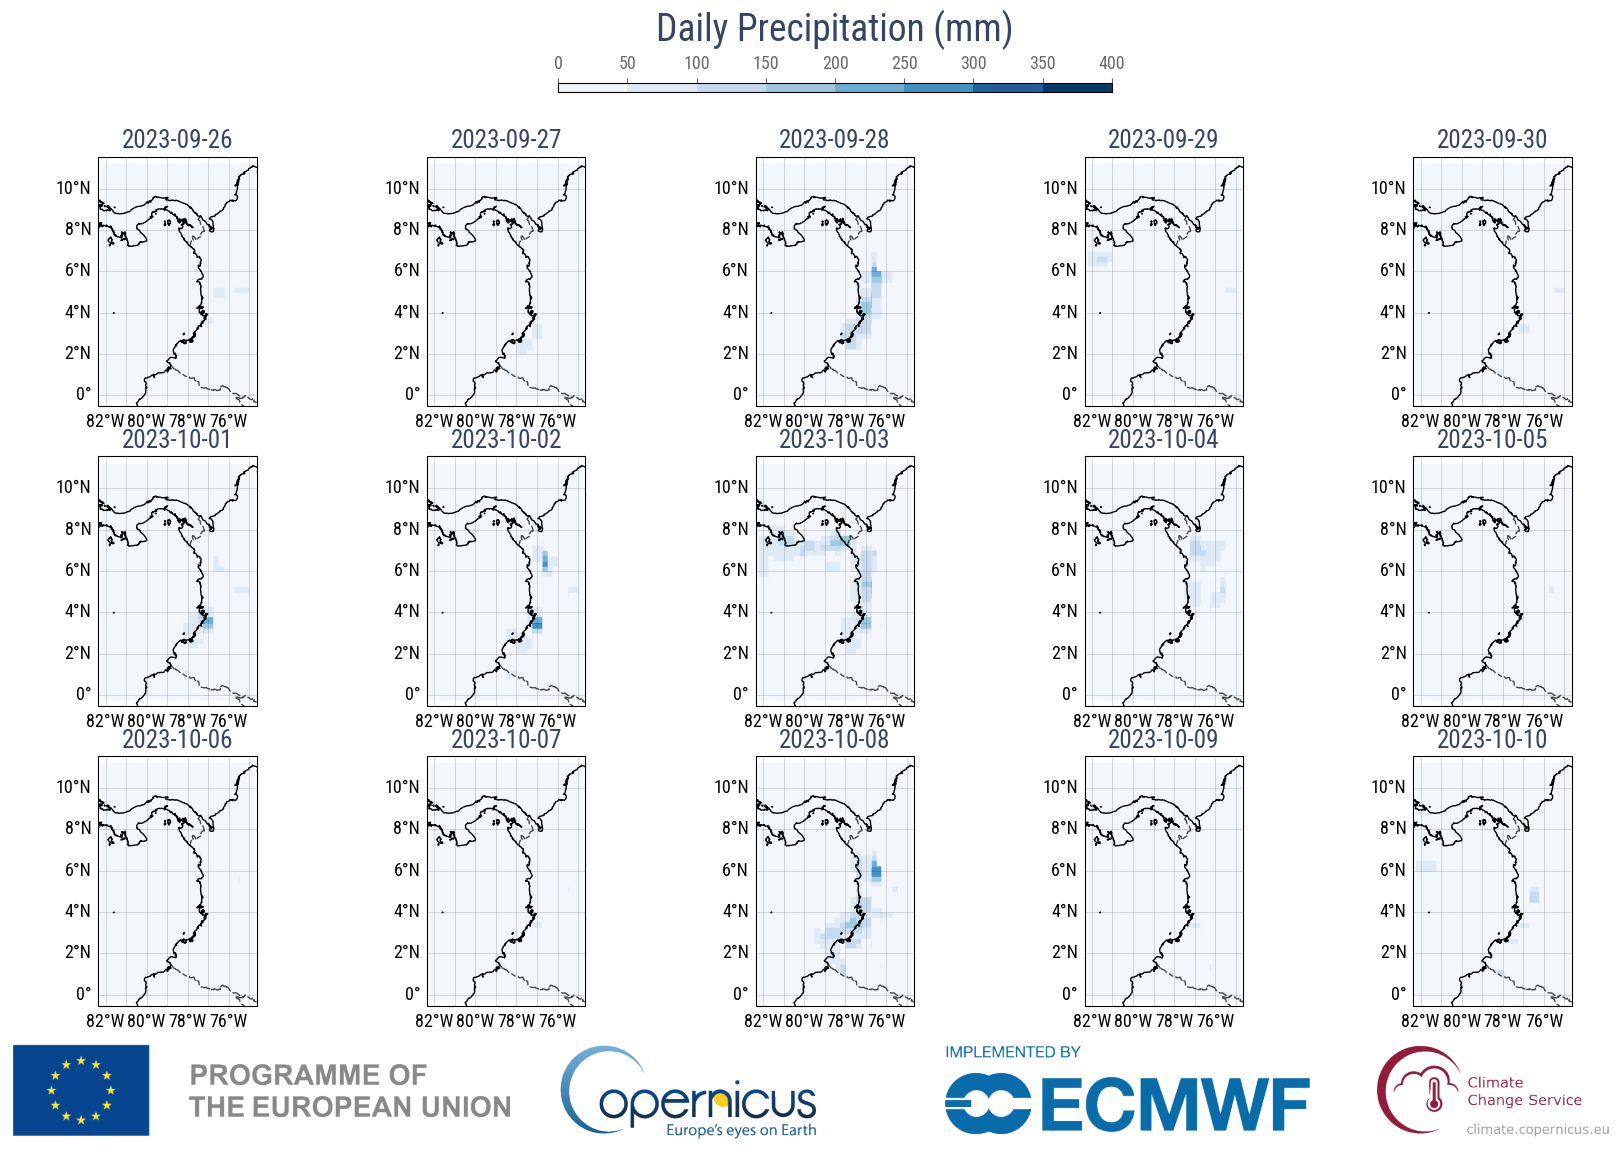

In [7]:
# Specify the title
if parameter in ["Tmax", "Tmean", "Tmin"]:
    title=f'Daily {variable.capitalize()} ({unit})'
else:
    title=f'Daily {variable.capitalize()} ({unit})'

fig, axes, img_ax = subplot_gdf(gr_daily_eventNdays, datetime_col=datetime_col, value_col=value_col, ncols=5, legend_title=title)

## 2.2.a.ii Compute and Visualize Event Anomalies
In this step, we compare the observed event with the long-term conditions.  
We first calculate a **30-day running mean climatology** (±15 days) using the 1991–2020 baseline period.  
This smoothed climatology helps remove day-to-day variability and highlights persistent deviations from normal.


### <font color="green"> Compute the 30-Day Running Mean Climatology (1991–2020) </font>
This step calculates the smoothed climatology for each day of the year, using a 30-day window (±15 days).
It averages all years between 1991 and 2020 to create a stable reference dataset. Additionally, we extract the event period from the smoothed climatology

In [8]:
# Calculate 31 smoothed mean for 1991-2020
clim31d = calculate_climatology(gr_daily_clim, value_col=value_col, padding=15, event_date=event_end)

clim31d_eventNdays = subset_gdf(gdf=clim31d, datetime_col=datetime_col, doy_range=(event_start.timetuple().tm_yday, event_end.timetuple().tm_yday))
clim31d_eventNdays

,longitude,latitude,tp,doy,geometry,valid_time
349740,-82.0,0.00,0.423994,269,POINT (-82 0),2023-09-26
349741,-82.0,0.25,0.424775,269,POINT (-82 0.25),2023-09-26
349742,-82.0,0.50,0.505945,269,POINT (-82 0.5),2023-09-26
349743,-82.0,0.75,0.545434,269,POINT (-82 0.75),2023-09-26
349744,-82.0,1.00,0.596374,269,POINT (-82 1),2023-09-26
...,...,...,...,...,...,...
369310,-75.0,10.00,8.508595,283,POINT (-75 10),2023-10-10
369311,-75.0,10.25,6.909143,283,POINT (-75 10.25),2023-10-10
369312,-75.0,10.50,7.605026,283,POINT (-75 10.5),2023-10-10
369313,-75.0,10.75,9.223336,283,POINT (-75 10.75),2023-10-10


### <font color="green"> Save the Climatology Dataset </font>
Once the climatology is computed, it is saved as a GeoPackage (.gpkg) file.
This ensures you can reuse the climatology later without recalculating it.

In [9]:

df = clim31d_eventNdays.drop(columns="geometry")
# Convert to xarray Dataset
ds = xr.Dataset.from_dataframe(df.set_index(["valid_time", "latitude", "longitude"]))
# Define save path
climatology_save = "climatology_1991-2020"
save_path = os.path.join(your_save_directory, f"{climatology_save}.nc")
# Save to NetCDF
ds.to_netcdf(save_path)

### <font color="Green"> Visualize Daily Anomalies During the Event </font>
Finally, we calculate and plot the absolute anomaly for each day of the event period, in case the of precipitation, the relative anomaly is calculated:

$Anomaly=Event Value−Climatology Value$

$Relative Anomaly=(Event Value−Climatology Value)/Climatology  Value$

The output shows 15 daily maps, allowing users to visualize how the anomaly evolved in space and time.

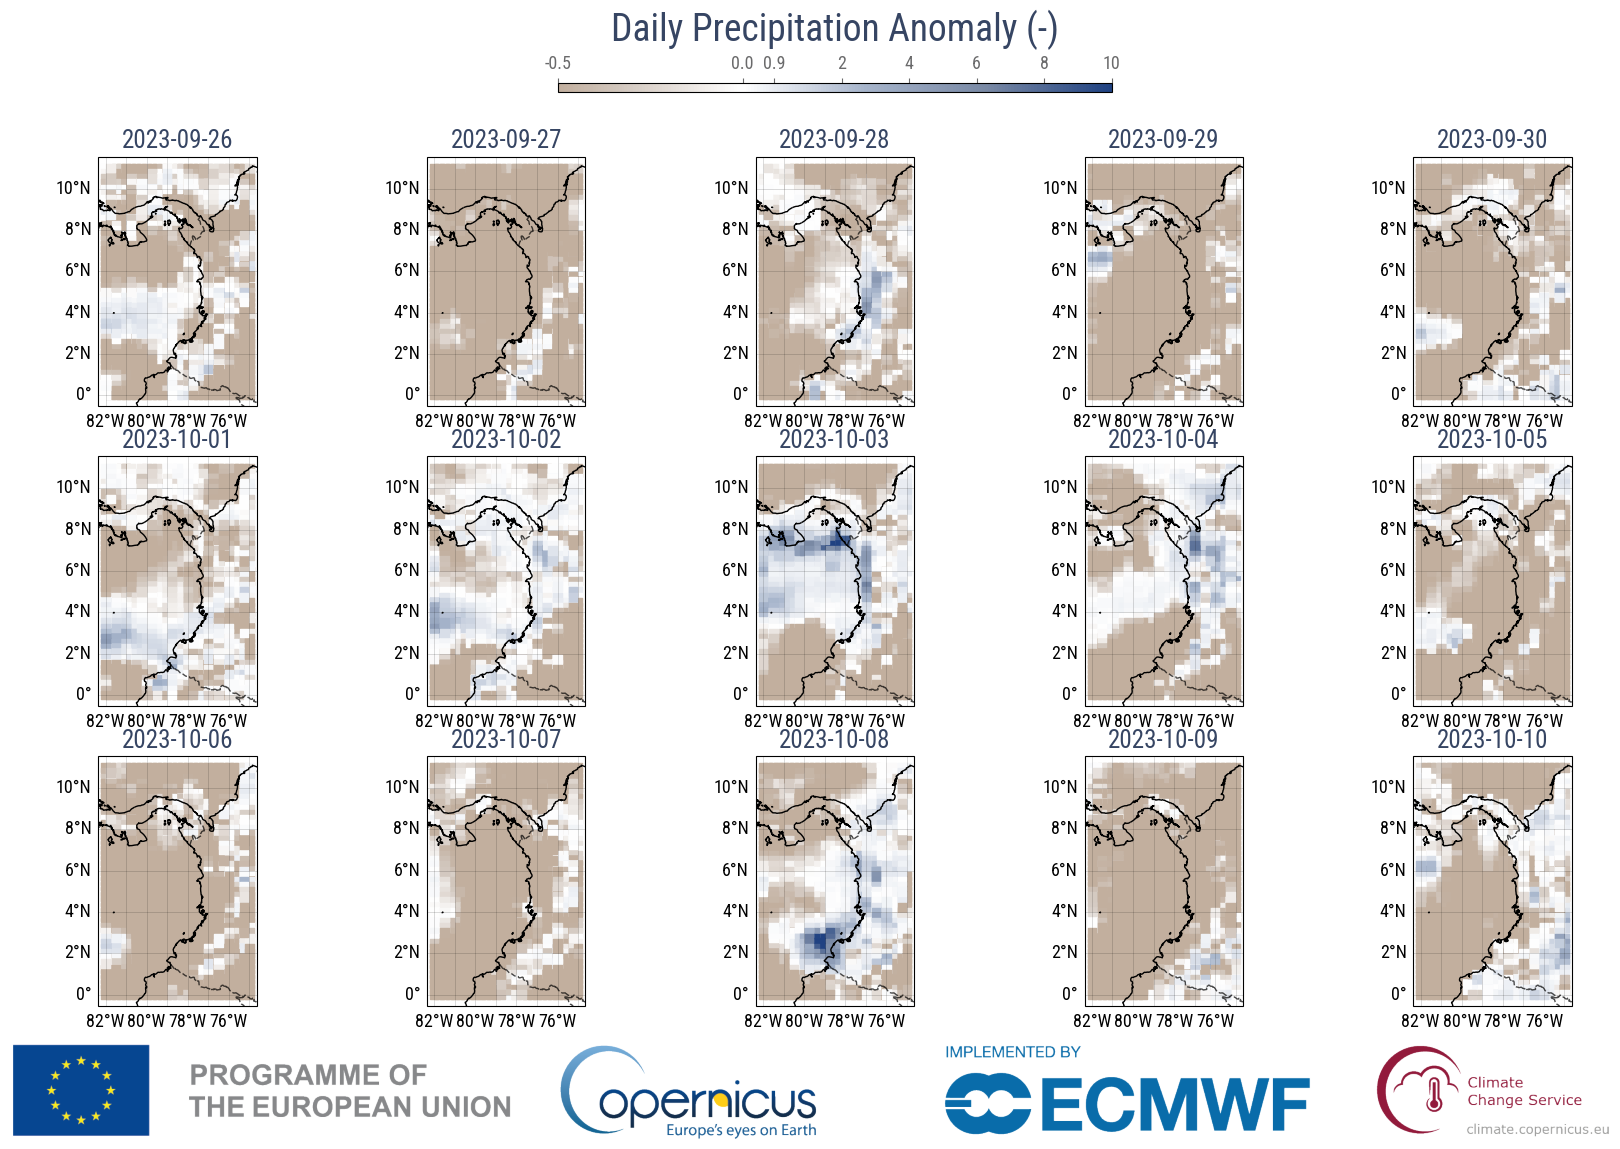

In [10]:
# Specify the title
if parameter in ["Tmax", "Tmean", "Tmin"]:
    title=f'Daily {variable} Anomaly ({unit})'
else:
    title=f'Daily {variable} Anomaly (-)'

# Calculate the anomaly for the days leading up to the event
gr_anom_eventNdays = calculate_anomaly(event_gdf=gr_daily_eventNdays, mean_climatology_gdf=clim31d_eventNdays, value_col=value_col, datetime_col=datetime_col, calcation=calculation)
fig, axes, img_ax = subplot_gdf(gr_anom_eventNdays,datetime_col=datetime_col, value_col=value_col, ncols=5, legend_title=title, cmap='anomaly')

## <font color="orange"> 2.2.b Choose a Day for Spatial Overlays (Steps 2.c–2.g) </font>
Pick a single representative day during the event to use for interactive region selection and inspection. This single-day snapshot is used to visually choose and test region overlays (e.g., river basins or administrative regions) that will be used for the spatial event definition.

Notes:
- The choice of day affects the visual overlays only, the subsequent analyses can use the full event period.  

In [11]:
############ Selected date (User selection) ##########
selected_date = datetime(2023, 10, 10)
######################################################


### <font color='orange'>Optionally select different or more overlays</font>


In [12]:
# Overlay images
anomaly_img = get_base_fig(selected_date, gr_anom_eventNdays, value_col=value_col)      # Anomaly
event_img = get_base_fig(selected_date, gr_daily_eventNdays, value_col=value_col)  # Event
overlays = {
    "anomaly": anomaly_img,
    "event": event_img
}

## <font color="green"> 2.2.c & 2.2.d Define and Select the Event Region </font>
In this step, you will visually inspect the event map and select one or more regions that represent the spatial extent of the event.
The goal is to define a realistic event region, large enough to capture the full impact area.
Regions are selected interactively in the browser using the region picker.

Notes:
- To avoid selection bias (maximising the extremity of the event) the regions selected should be a larger area that encompasses the main event rather than selecting only the area of maximum intensity.

The region picker will shortly open in your web browser. Please select a region, close the browser tab and return to the notebook when done.
Region Picker started successfully for hydrobasin:
Polling for region selection...
Region selection process done.
Received polygon data:
{"type":"FeatureCollection","features":[{"type":"Feature","properties":{"merge_key":"1"},"geometry":{"type":"Polygon","coordinates":[[[-77.7464,7.6674],[-77.7453,7.6436],[-77.7411,7.6382],[-77.7422,7.627],[-77.7453,7.623],[-77.7458,7.6167],[-77.7452,7.6092],[-77.7382,7.6074],[-77.7369,7.5978],[-77.7338,7.5938],[-77.7381,7.5882],[-77.7369,7.5853],[-77.7339,7.5814],[-77.7328,7.5728],[-77.7256,7.5647],[-77.7244,7.5603],[-77.7214,7.5564],[-77.7203,7.552],[-77.7172,7.548],[-77.716,7.5384],[-77.7105,7.5339],[-77.7083,7.5333],[-77.708,7.5226],[-77.7038,7.5184],[-77.7045,7.5017],[-77.7087,7.4975],[-77.708,7.4934],[-77.7038,7.4892],[-77.7045,7.4809],[-77.7087,7.4767],[-77.708,7.4726],[-77.7004,7.4649],[-77.7,7.4625],[-77.

d:\Git\c3s-451\.venv\Lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
C:\Users\daniel\AppData\Local\Temp\ipykernel_32492\2904273110.py:12: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")


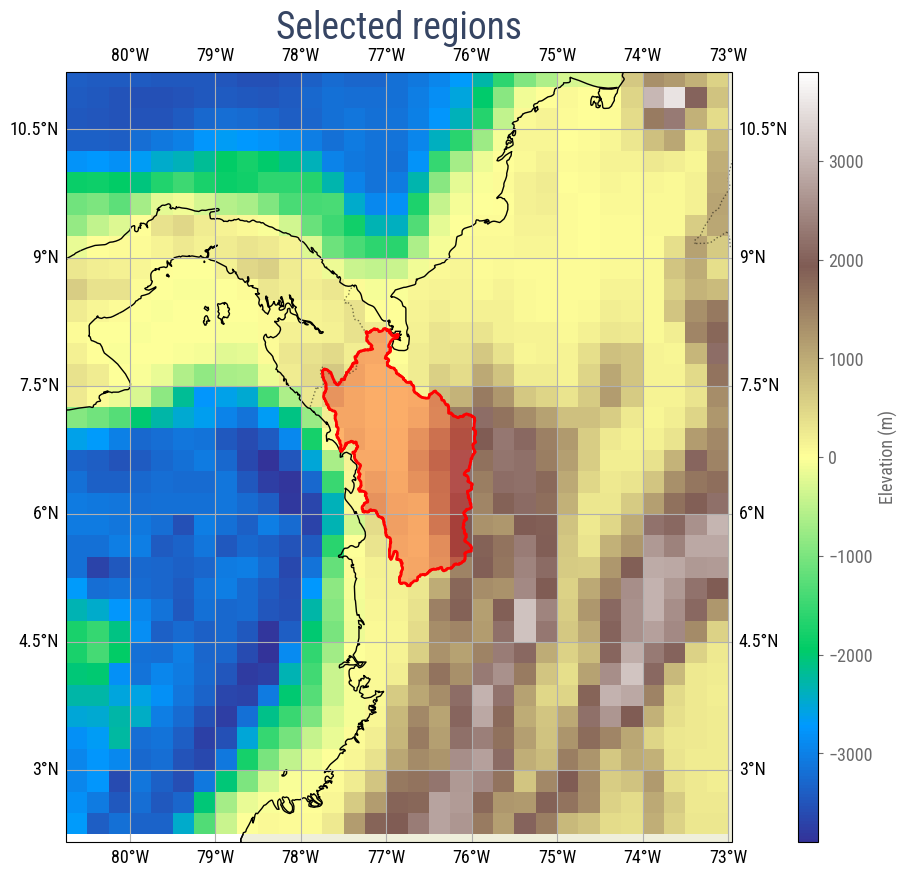

In [13]:
# regiontype wraf for temperature, hydrobasin for precipitation
if parameter in ["Tmax", "Tmean", "Tmin"]:
    region_type = 'wraf'
elif parameter == "Precipitation":
    region_type = 'hydrobasin'

result = select_region(regionType=region_type, bbox=bbox, overlays=overlays) 
data = json.loads(result)

polygons, coords = data_2_poly(data)

elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")
elevation = wrap_lon(elevation_nc)['data']

fig, ax = plot_poly(polygons, coords, elevation=elevation)

## <font color="orange"> 2.2.e Apply an Elevation Threshold </font>

In this step, you can refine the event region by removing areas above a certain elevation.
This is useful when your region includes mountains or strong elevation gradients that could distort averages (for example, separating coastal plains from nearby highlands).

The tool will overlay topography on your selected event region so you can decide whether to apply an elevation cutoff.

Notes:
- Run this cell as much as need it to ensure the region is topographically homogeneous.

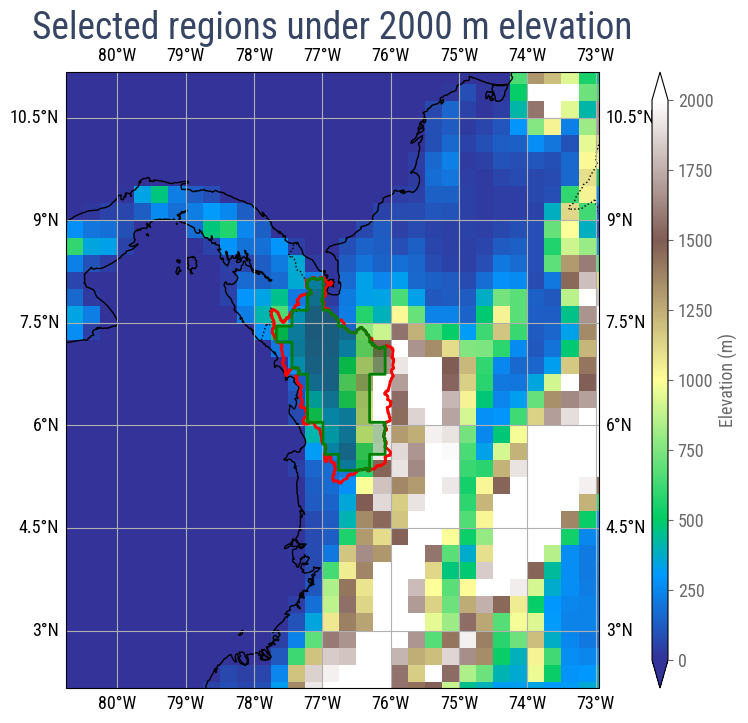

In [14]:
################### Select an elevation threshold (User selection)  ########################
################### the studyregion is selected as all areas below the threshold ###########
elevation_threshold = 2000 # meters
############################################################################################

# The adjusted_polygons are later used for visualizing the studyregion in the plots
fig, ax, adjusted_polygons = elevation_region(data, polygons, elevation, elevation_threshold)

## <font color="orange"> 2.3  Save the study domain </font>

This step saves the final event region (also called the study domain) that you defined in the previous steps.


In [15]:
############ Specify name for saving the shapefile (User selection) ############
shapefile_save = "sf_studyregion"
###############################################################################

# the studyregion is used for masking the geospatial data
multipoly = unary_union(adjusted_polygons)
studyregion = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[multipoly])    #is this using the correct CRS?
studyregion.to_file(os.path.join(your_save_directory, f"{shapefile_save}.shp"))
#polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
#polygons_gdf.to_file("../data/sf_polygons.shp")

## <font color="green"> 2.4 Create and Save the Daily Time Series </font>

In this step, the daily values of the chosen climate variable (e.g., temperature, precipitation) are averaged over the study domain you defined earlier.
This produces a single daily time series representing the evolution of the event across the region. The time series is saved and it will be reuse in further steps.

In [16]:
# Specify name for saving the daily timeseries 
daily_timeseries_save = "ts_daily_studyregion"


# climatology_1950_event_studyregion = gpd.overlay(climatology_1950_event, studyregion, how='intersection')
gr_daily_studyregion = subset_gdf(gdf=gr_daily, study_region=studyregion)

# give eacht cell a weight based on its size (latitude related)
gr_daily_studyregion_weighted = weighted_values(gr_daily_studyregion, value_col)

# calculate spatial mean
ts_daily_studyregion = calculate_mean(gdf= gr_daily_studyregion_weighted,
                                                                value_col=value_col, groupby_col=datetime_col)

#spatialmean_climatology_1950_event_studyregion = climatology_1950_event_studyregion.groupby(datetime_col)[value_col].mean().reset_index()
ts_daily_studyregion.to_xarray().to_netcdf(f"{your_save_directory}/{daily_timeseries_save}.nc")
ts_daily_studyregion

print(type(ts_daily_studyregion))

<class 'pandas.core.frame.DataFrame'>


d:\Git\c3s-451\library\c3s_lib\process.py:403: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[f"{value_col}_weighted"].sum() / x["_weight"].sum())


## 2.5 Calculate and Compare n-Day Aggregated Values

This step aggregates  the daily data into n-day averages or accumulations to analyze how the event compares to the historical annual time series in the study region. (n-day accumulations for precipitation and n-day averages for temperature)
It helps to evaluate the event’s intensity, duration, and persistence at standard time scales.

Comparing these values to the hsitorical events helps identify whether the event was exceptional or within normal variability.

### <font color='orange'>Select Parameters</font>

This cell automatically configures the n-day aggregation settings based on the variable you’re analyzing:
- **Precipitation:** uses 1-, 3-, 5-, and 10-day totals.  
- **Temperature:** uses 1-, 3-, 7-, and 14-day averages.  

You can adjust optional parameters (e.g., centering or quantile) if needed.  
Run the cell below to confirm your settings before continuing.

In [17]:

############# User Selection #############
# method: mean, sum, std, quantile
method = None
centering = False

# if method quantile is selected
quantile = .9

###########################################

if parameter in ["Tmax", "Tmean", "Tmin"]:
    days = [1, 3, 7, 14]
    title = f"Average {variable} ({unit})"
    if method == None:
        method = 'mean'
elif parameter == "Precipitation":
    days = [1, 3, 5, 10]
    title = f"Total {variable} ({unit})"
    if method == None:
        method = 'sum'
if method == 'quantile':
    title = f'Precipitation {int(quantile*100)}th Percentile ({unit})'
elif method == 'std':
    title = f'Precipitation Variability ({unit})'


### <font color="green"> Compute and Plot n-Day Averages or Accumulations </font>

The code below computes the n-day moving average (for temperature) or accumulation (for precipitation) and plots each time series for comparison.
These plots help visualize how each timescale smooths or amplifies the event’s intensity.

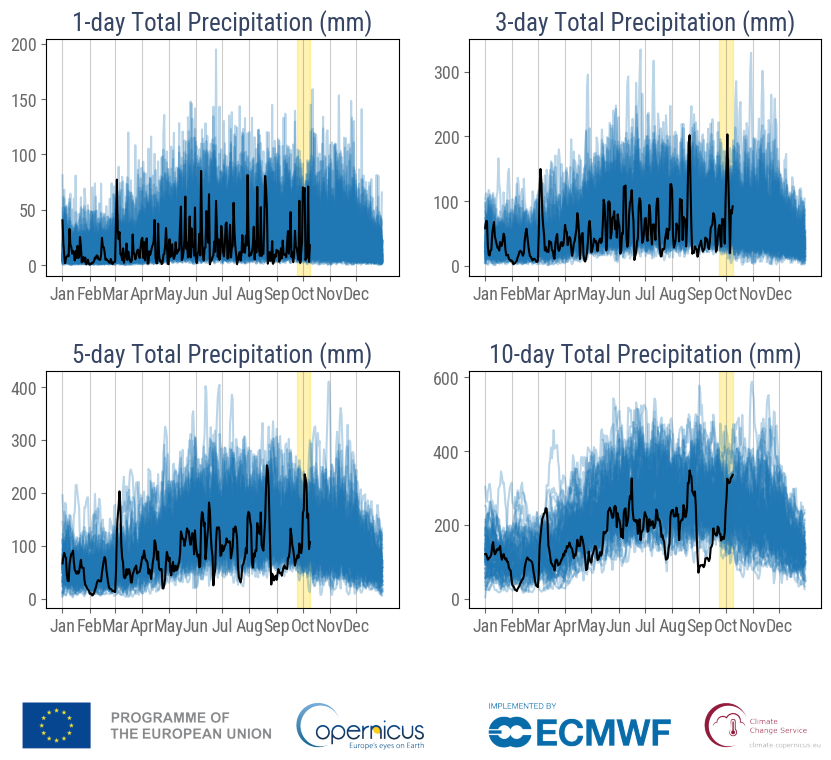

In [18]:
# calculate n-day rolling values
rolled_data_list = [calculate_rolling_n_days(gdf=ts_daily_studyregion,
                                            value_col=value_col, datetime_col=datetime_col,
                                            padding=d, centering=centering, method=method, quantile=quantile) for d in days]

# labels and label ticks
labelticks = pd.date_range("2000-01-01", "2000-12-31", freq="MS").dayofyear
labels = pd.date_range("2000-01-01", "2000-12-31", freq="MS").strftime("%b")

# plot timeseries
fig, axes, img_ax = plot_n_days(rolled_data_list, value_col=value_col, parameter=parameter,
                                event_date=event_end, labelticks=labelticks, labels=labels,
                                days=days, title=title, fig_height=4, ncols=2)

## <font color='green'> 2.6 Analyze, Plot and Save the Seasonal Cycle (1991–2020) </font>

The seasonal cycle represents how the chosen climate variable typically evolves over the course of a year, based on the long-term climatology (1991–2020). Two plots are shown to account for the fact that the timing of summer and winter seasons differs between the Northern and Southern Hemispheres

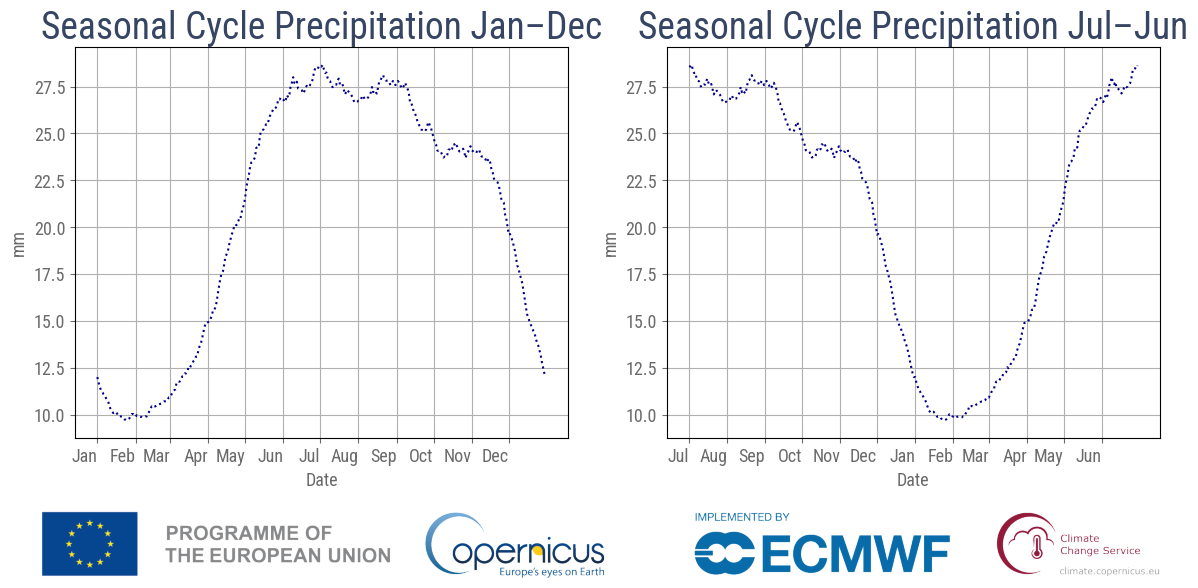

<Figure size 640x480 with 0 Axes>

In [19]:
# Calculating the annual climatology (1991-2020) time series for the studyregion and plotting the seasonal cycles

y_label = unit
title1 = f"Seasonal Cycle {variable} Jan–Dec"
title2 = f"Seasonal Cycle {variable} Jul–Jun"

figs, axes = plt.subplots(1, 2, figsize=(14, 6))

#  Compute both seasonal cycles
ts_clim31d_studyregion, plot_df1, labels1, labelticks1 = calculate_seasonal_cycle(clim31d, studyregion, (1, 12), value_col, datetime_col, event_end)
ts_clim31d_studyregion2, plot_df2, labels2, labelticks2 = calculate_seasonal_cycle(clim31d, studyregion, (7, 6), value_col, datetime_col, event_end)

plot_timeserie(data=plot_df1, value_col=value_col, datetime_col="plot_time", title=title1,
        x_label="Date", y_label=y_label, line_style=":", labels=labels1,
        labelticks=labelticks1, add_logos=False, ax=axes[0]
    )

plot_timeserie(data=plot_df2, value_col=value_col, datetime_col="plot_time", title=title2,
    x_label="Date", y_label=y_label, line_style=":", labels=labels2,
    labelticks=labelticks2, add_logos=True, ax=axes[1]
)

axes[1].set_xlim(plot_df2["plot_time"].min(), plot_df2["plot_time"].max())
plt.tight_layout()
plt.show()


### <font color="orange"> Save the Seasonal Cycle Outputs </font>
Save the computed seasonal cycle data and the plot for future reference.

In [20]:
################# User Selection  ##################
#Please specify names for saving the dataframe and figure 
# time series save
seasonal_cycle_series_save = 'seasonal_cycle_1991-2020'

# figure save
seasonal_cycle_figure_save = 'seasonal_cycle_1991-2020'
#####################################################


# save the time serie
ds = xr.Dataset.from_dataframe(ts_clim31d_studyregion.set_index(datetime_col))
ds.to_netcdf(os.path.join(your_save_directory, f"{seasonal_cycle_series_save}.nc"))

# save the figure
fig.savefig(fname=os.path.join(your_save_directory, f"{seasonal_cycle_figure_save}.png"), dpi=150, bbox_inches="tight")

## 2.7 Decide on the temporal extent  
Use **Step 2.2** and the following considerations:

#### a. As much related to impacts as possible
- e.g. `TXx` (max Temperature 1-day, outdoor workers)  
- e.g. `T3x` (mean Temperature 3-day, people indoors)  
- e.g. Flooding: precipitation averaged over duration or over response time basin  
- e.g. Drought: precipitation values (or soil moisture) averaged over several months or multiple rainy seasons  

#### b. Seasonality
- **OPTIONAL:** Use information from literature review (see also Sec. 6a.), specifically for information on seasonality, that can feed into the choice of event definition.  
- Make use of seasonal cycle plot  
- Restrict to some months if necessary, e.g. if event occurred outside of the usual season or a change in seasonality is suspected  
  - Example: May–June maximum 4-day precipitation  
- Potentially take temperature anomalies rather than absolute values if averaging over months where the seasonal cycle is in transition between peaks and troughs  

#### c. Make use of the plots created in Step 2.5

## 2.8 Make a final decision on the event definition  
Update the output table in the tables document (apart from the last row on return period).

#### a. Write down in the Jupyter Notebook the factors that informed the specific event definition  
Use the following considerations as a guide to single out which aspect of the multifaceted nature of the extreme is chosen for emphasis and communication:

- **Variable:**  
  - `Tmax`, `Tmin`, or `Tmean` – were the daily maxima or the high nighttime minima or both the most defining for the heat event?  

- **Timing:**  
  - Is it the early-season onset of the event that made it anomalous (only) for the time of year, giving locals little time to adjust?  

- **Seasonality:**  
  - Is it specific for a single season only, in case of multiple peaks in the seasonal cycle?  

- **Duration:**  
  - Is it daily record-breaking extremes that will dominate headlines?  
  - Or the long persistence of heat that will also impact indoor conditions, drought, or fire weather, and be felt more than one day of exceptional heat?  

- **Spatial:**  
  - Is the large spatial extent of the event particularly noteworthy over other factors and in comparison to previous similar events in the region?  
  - Or is it that the event location coincides with a densely populated area that makes it particularly noteworthy?  

In [21]:
#number of days (maximum/mean/minimum of 3 day averages - couple of days from months around selection are needed)
#minimum/maximum / mean
#jan-dec, july-june, specific months (may-june only for example)

## 2.9 Create and Save the Annual Time Series
This step creates an annual time series. For each year in the dataset, one representative value is calculated, such as:

- The mean temperature for each year over the month range indicated, or
- The max total precipitation accumulated during the event period.

This allows for long-term comparison of how the event intensity varies from year to year.

### <font color='orange'>Select Parameters</font>

You can adjust optional parameters if needed. Run the cell below to confirm your settings before continuing.

In [22]:
################### User Selection  ##################
# mean, max. min
yearly_value = 'max'

# padding >= 1 : rolling mean, rolling window, n-days (centered)
padding = 10

# (1, 12) V (12,1)
month_range = (1, 12)

# Standard method for temperature: mean and for precipitation: sum, if not specified
# if you want to change it, specify here
method = None 

#######################################################

# Automatically generate month range label and title
start_month_name = calendar.month_abbr[month_range[0]]
end_month_name = calendar.month_abbr[month_range[1]]
# Handle different types of ranges
if month_range[0] < month_range[1]:
    # Normal within-year range (e.g., May–June)
    month_label = f"{start_month_name}–{end_month_name}"
else:
    # Cross-year range (e.g., Dec–Feb)
    month_label = f"{start_month_name}–{end_month_name} (cross-year)"

y_label = unit

line_style='-'  

draw_style='steps'

if parameter in ["Tmax", "Tmean", "Tmin"]:
    title = f"{month_label} {yearly_value.capitalize()} {variable.capitalize()} ({unit})"
    if method is None:
        method = 'mean'
elif parameter == "Precipitation":
    title = f"{month_label} {yearly_value.capitalize()} Total {variable.capitalize()} ({unit})"
    if method is None:
        method = 'sum'


#### <font color="green"> Calculation and plotting </font>
The script computes one value per year, then plots it.
This visualization helps identify long-term changes, extremes, or trends in the event’s intensity.

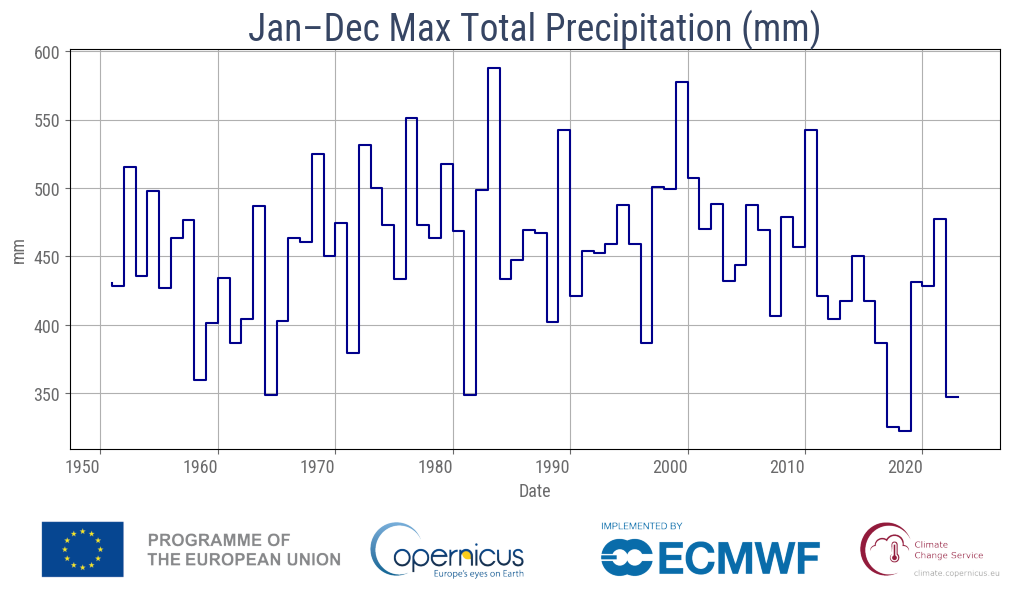

In [23]:
# # Optionally the juli-june yearly value can be calculated by shifting the dates by 6 months
# shifted_dates = shift_datetime_by_months(gdf=spatialmean_climatology_1950_event_studyregion,
#                                          datetime_col=datetime_col, shift_by=6, direction='backward')

# Example maximum 3 day running mean yearly maximum
ts_ann_studyregion = calculate_yearly_value(gdf=ts_daily_studyregion,
                                            value_col=value_col, datetime_col=datetime_col,
                                            yearly_value=yearly_value, padding=padding,
                                            month_range=month_range, method=method)

# plot
fig, ax, img_ax = plot_timeserie(data=ts_ann_studyregion, value_col=value_col,
                                 datetime_col='year', title=title, x_label='Date',
                                 y_label=y_label, line_style=line_style, draw_style=draw_style)

### <font color='orange'> Saving output </font>
Save the resulting annual time series as a NetCDF file for analysis and data exchange

In [24]:
################### User Selection  ##################
# Please specify name for saving the annual time series
annual_timeseries_save = 'ts_ann_studyregion'
#######################################################

ds = xr.Dataset.from_dataframe(ts_ann_studyregion.set_index("year"))
ds.to_netcdf(os.path.join(your_save_directory, f"{annual_timeseries_save}.nc"))

## 2.10 Read in station data time series from a CSV file

### <font color='orange'>Optionally load in data from a csv or xls file</font>

In [25]:
# # CSV
# separator = ','
# encoding = 'utf-8'
# file_name = 'my_file.csv'   # optionaly add directory
# df = pd.read_csv(file_name, sep=separator, encoding=encoding)

In [26]:
# XLS
# read station data time series from .xls
#xls_station_data = pd.ExcelFile("../data/example.xlsx")
#print(xls_station_data.sheet_names)   # list available sheets
#xls_station_data_sheet1 = pd.read_excel(xls_station_data, "Sheet1")
#xls_station_data_sheet2 = pd.read_excel(xls_station_data, "Sheet2")

In [27]:
#number of days (maximum/mean/minimum of 3 day averages - couple of days from months around selection are needed)
#minimum/maximum / mean
#jan-dec, july-june, specific months (may-june only for example)

## 2.11 Create Event Map

This steps produce a figure of the event (Averaged over the selected temporal event definition). Adittionally, the event anomaly map is produced as well and an overlay of the study region is included

### <font color='orange'>Parameters</font>

You can adjust optional parameters if needed. Run the cell below to confirm your settings before continuing.

In [28]:
################### User Selection  ##################
# Event colors
event_poly_col = 'cyan'
anomaly_poly_col = 'lime'

# possible free user input for an input date + padding
# uncomment if you want to select a different date and/or padding
selected_date = pd.to_datetime('2023-10-9')  
padding = 1

#######################################################

if parameter in ["Tmax", "Tmean", "Tmin"]:
    event_title = 'Mean Temperature'
    anomaly_title = 'Mean Temperature Anomaly'
    y_label = '(°C)'
    y_label_anom = '(°C)'
elif parameter == "Precipitation":
    event_title = 'Total Precipitation'
    anomaly_title = 'Total Precipitation Anomaly'
    y_label = '(mm)'
    y_label_anom = '(-)'

### <font color="Green"> Calculation and plotting</font>

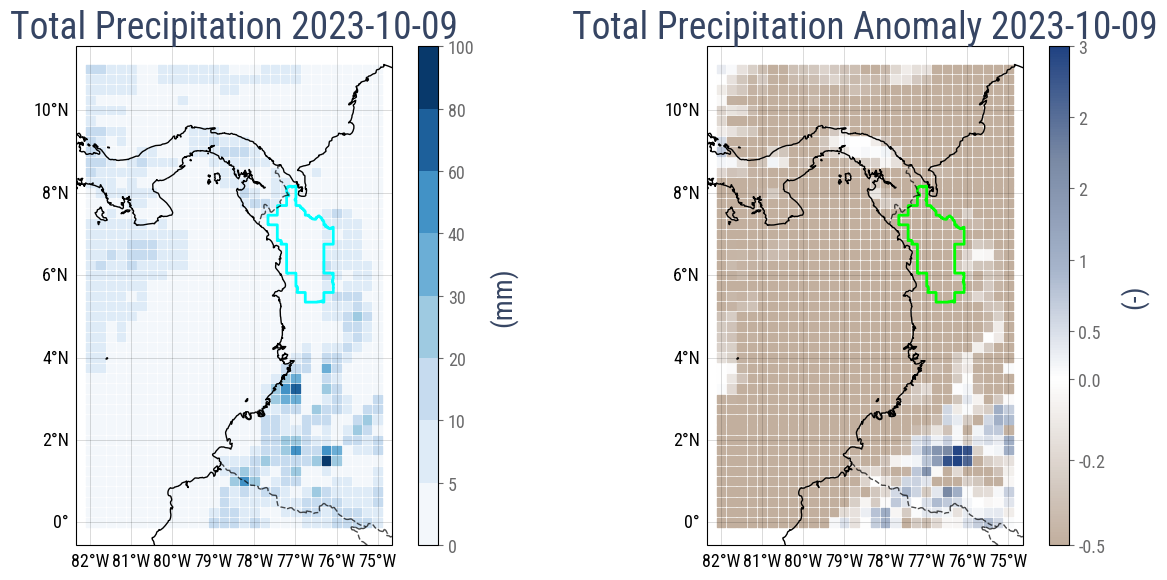

In [29]:
# if selected_date is None, the last date of the annual time series is used
selected_date = selected_date if selected_date else pd.to_datetime(ts_ann_studyregion[datetime_col].iloc[-1])

## add padding around the selected date
pad = math.floor(padding/2)
selected_date_start = selected_date - timedelta(days=pad)
selected_date_end = selected_date + timedelta(days=pad)

# event selection
selected_intersect = subset_gdf(gdf=gr_daily_eventNdays, datetime_col=datetime_col,
                                date_range=(selected_date_start, selected_date_end))
# anomaly selection
selected_intersect_anomaly = subset_gdf(gdf=gr_anom_eventNdays, datetime_col=datetime_col,
                                        date_range=(selected_date_start, selected_date_end))

# average
selected_event_mean = calculate_mean(gdf=selected_intersect, value_col=value_col, groupby_col=['longitude', 'latitude', 'geometry'])
selected_anomaly_mean = calculate_mean(gdf=selected_intersect_anomaly, value_col=value_col, groupby_col=['longitude', 'latitude', 'geometry'])

# create subplot
figs, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# plot event
fig, ax = plot_gdf(selected_event_mean, value_col=value_col, ax=axes[0],
                     title=f"{event_title} {selected_date.strftime('%Y-%m-%d')}",
                     legend_title=y_label, add_logos=False, polygons=adjusted_polygons, polygon_color=event_poly_col)
# plot anomaly
fig, ax = plot_gdf(selected_anomaly_mean, value_col=value_col, ax=axes[1],
                     title=f"{anomaly_title} {selected_date.strftime('%Y-%m-%d')}",
                     legend_title=y_label_anom, add_logos=False, polygons=adjusted_polygons, polygon_color=anomaly_poly_col, cmap='anomaly')

plt.tight_layout()
plt.show()

## 2.12 Write a paragraph on the event definition in the scientific report Section 1.

## 2.13 Meteorological maps including the event.

Z500 (500 hPa Geopotential Height) – shows the height of the 500 hPa pressure surface (~5–6 km). It reveals mid-tropospheric circulation: high values mark warm ridges and low values mark cold troughs that steer large-scale weather patterns.

SLP (Sea-Level Pressure) – displays surface pressure distribution (in hPa). Low-pressure systems (cyclones) and high-pressure systems (anticyclones) control winds, fronts, and rainfall patterns near the surface.

### <font color='green'>Parameters, countours and plotting</font>

Connected to: https://beacon-development.maris.nl/ server successfully
Connected to: https://beacon-development.maris.nl/ server successfully


2025-10-31 17:07:51,657 INFO Request ID is 4d527ed3-dcfa-4ec8-91d9-9cacf0b5bc8d
2025-10-31 17:07:51,720 INFO status has been updated to accepted
2025-10-31 17:08:05,213 INFO status has been updated to running
2025-10-31 17:08:12,881 INFO status has been updated to successful


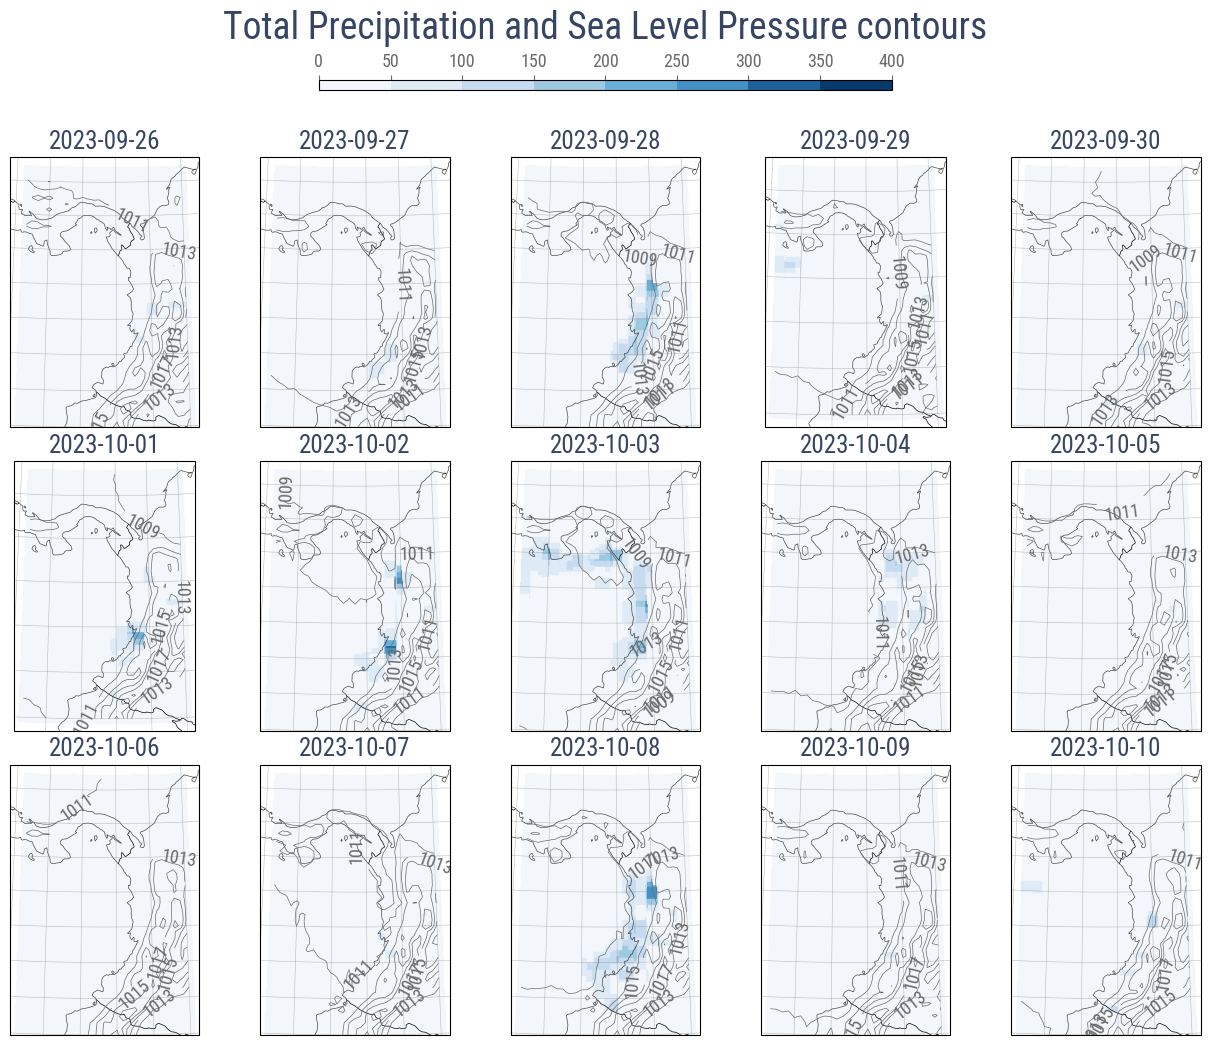

d:\Git\c3s-451\library\c3s_lib\plot.py:1010: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [30]:

if variable == 'Temperature':
    contour = 'z500'
    contour_col = 'z'
    legend_title = 'ERA5 Z500 and T2M'
    contour_steps = 250
elif variable == 'Precipitation':
    contour = 'SLP'
    contour_col = 'msl'
    legend_title = 'Total Precipitation and Sea Level Pressure contours'
    contour_steps = 2

contour_gdf = DataClient(your_api_key, beacon_cache_url='https://beacon-development.maris.nl').GET(parameter=contour, bbox=bbox, time_range=(event_start, event_end))

if contour_col == 'msl':
    contour_gdf[contour_col] = contour_gdf[contour_col] / 100

fig = subplot_contours(contour_gdf, gr_daily_eventNdays, datetime_col=datetime_col,
                      value_col=value_col, contour_col=contour_col, ncols=5,
                      contour_steps=contour_steps, legend_title=legend_title)


## 2.14 Describe the event and meteorology in the scientific report Introduction

- a. Describe meteorological situation, using maps created in Step 2.13 and the event maps
created in Step 2.11
- b. Use information from seasonality
- c. Placeholder step to include a more elaborate event description by C3S, based on event
monitoring
- d. Placeholder step to include a more elaborate event description by local NMS

## 2.15 Average monthly climatology map

Monthly climatology field to be used for the model validation. For temperature or precipitation metrics this is the 1991-2020 mean of the chosen metric over the selected month/season.   

### <font color="green"> Calculation and plotting </font>

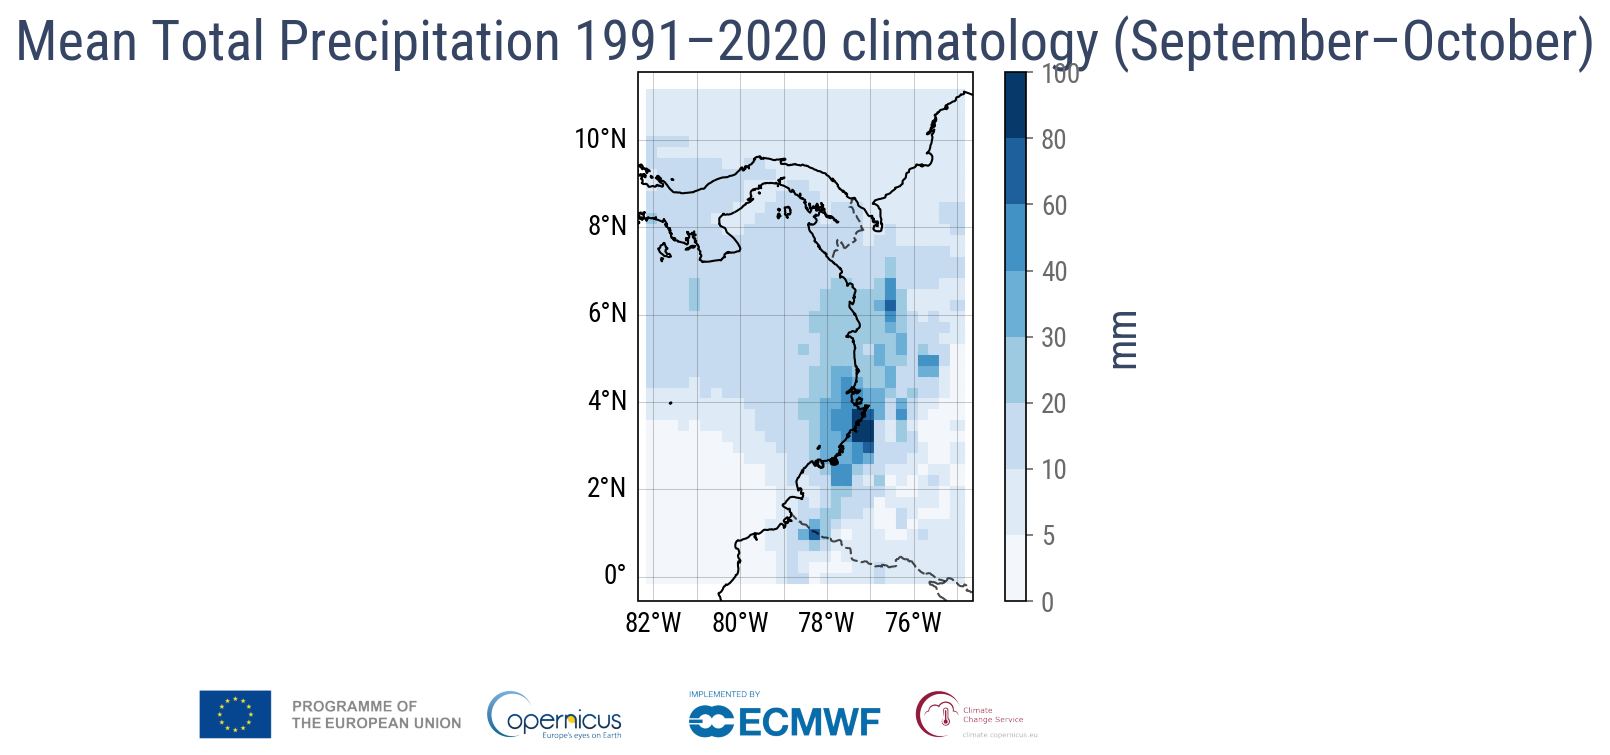

In [31]:
# automatically selects the month(s) of the event, can be overwritten by user
# Determine if event spans one or more months
start_month, end_month = event_start.month, event_end.month

# Handle wrap-around across year end (e.g., Nov–Feb)
if end_month < start_month:
    month_indices = list(range(start_month, 13)) + list(range(1, end_month + 1))
else:
    month_indices = list(range(start_month, end_month + 1))

# Convert to month names
month_names = [calendar.month_name[m] for m in month_indices]

# Define readable label
if len(month_names) == 1:
    period_label = month_names[0]
else:
    period_label = f"{month_names[0]}–{month_names[-1]}"  # e.g., May–June

# Choose appropriate title
if parameter in ["Tmax", "Tmean", "Tmin"]:
    title = f"Mean {variable} 1991–2020 climatology ({period_label})"
elif parameter == "Precipitation":
    title = f"Mean Total {variable} 1991–2020 climatology ({period_label})"

# Set unit label
y_label = unit
dpi = 150

# Subset climatology
month_gdf = subset_gdf(
    gdf=clim31d, datetime_col=datetime_col, year_range=(event_end.year, event_end.year), month_range=(start_month, end_month)
)

# Calculate average over months
monthly_avg_gdf = calculate_mean(
    gdf=month_gdf, value_col=value_col, groupby_col=['longitude', 'latitude', 'geometry']
)

# Plot
fig, ax, img_ax = plot_gdf(
    monthly_avg_gdf, title=title, legend_title=y_label, value_col=value_col, dpi=dpi
)


### <font color='orange'>Saving the monthly climatology</font>

In [32]:
################### User Selection  ##################
# Please specify names for saving the dataframe and figure
monthly_avg_gdf_save = "mean_temperature_june"

monthly_avg_figure_sace = "mean_temperature_june"
#######################################################

monthly_avg_gdf.to_file(os.path.join(your_save_directory, f"{monthly_avg_gdf_save}.gpkg"), layer='climatology', driver='GPKG')

fig.savefig(fname=os.path.join(your_save_directory, f"{monthly_avg_figure_sace}.png"), dpi=150, bbox_inches="tight")